# Homework Assignment 4

**Deadline:** 27 April 2026
<br><br>
**Student names:**: Subrahmanyan Chandrasekhar & Arthur Eddington ← **PLEASE REPLACE**
<br>
**Total hours spend:** ... h
<br><br>
**Important Remarks:**
<br>
* **Submitting the homework is a compulsory course component.** 
* Making mistakes or not always being able to completely solve an exercise is fine. The goal is to let you interactively explore the concepts from the lecture and identify common problems/misconceptions. If you could not solve/finish a task, please discuss why and what you tried using markdown cells.
* If you should have any questions please don't hesitate to ask them. This especially includes any questions on (astro)physical aspects of the exercises. You can use the discussions section in our Toledo Ultra course. Please do not give away your solution to problems to other student groups when using the discussions.
* Document what you are doing in markdown cells. Adding formulas is a good way to make your implementations in code easier to understand.
* Plots have to follow scientific standards. This includes the requirement of axis labels including measurement units if applicable!
* Indicate how much time you spend in total on this assignment.

**Submission Process:**
<br>
* Groups only need to submit a single notebook, there is no need for individual submissions.
* Rename the notebook as `HomeworkAssignment4_FirstnameLastname1_FirstnameLastname2.ipynb` where you insert your names in the filename.
* Send your notebook to both TAs (Dario Fritzewski: dario.fritzewski@kuleuven.be; Reinhold Willcox: reinhold.willcox@kuleuven.be) using the subject line "**Data Analysis Homework Submission 4**". You can make your notebook file smaller by deleting the outputs before submitting. If the notebook should still be too large for an email, please use [WeTransfer](https://wetransfer.com/).

⚠️ <font color='red' style='bold'><b>IMPORTANT:</b></font> You should solve at least one task analytically, i.e. without the use of sampling-based methods. We recommend to always try to come up with an analytical approach and optionally provide an additional MCMC based solution.

# Imports

In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
from matplotlib import pyplot as plt
from IPython.display import Image

# Feel free to change these defaults
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=18)     # fontsize of the axes title
plt.rc('axes',   labelsize=18)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=18)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=18)     # fontsize of the tick labels
plt.rc('legend', fontsize=18)      # legend fontsize
plt.rc('figure', titlesize=18)     # fontsize of the figure title
plt.rc('figure', dpi=75)           # Changed to 100 for some version >3.5.2

# Contents

1. [A trip to the casino](#Task-1:-A-trip-to-the-casino)
2. [Solar flares](#Task-2:-Solar-flares)
3. [Supernova neutrinos](#Task-3:-Supernova-neutrinos)

For the credits of the images, see [the homework page](https://github.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/blob/main/Images/credits.txt) of this course on Github.

---

## Task 1: A trip to the casino

The Gambler's fallacy refers to the erroneous belief that statistically independent events are affected by previous repeated outcomes. For instance, that after repeated rolls of black in a roulette, the following rolls are more likely to result in a red.

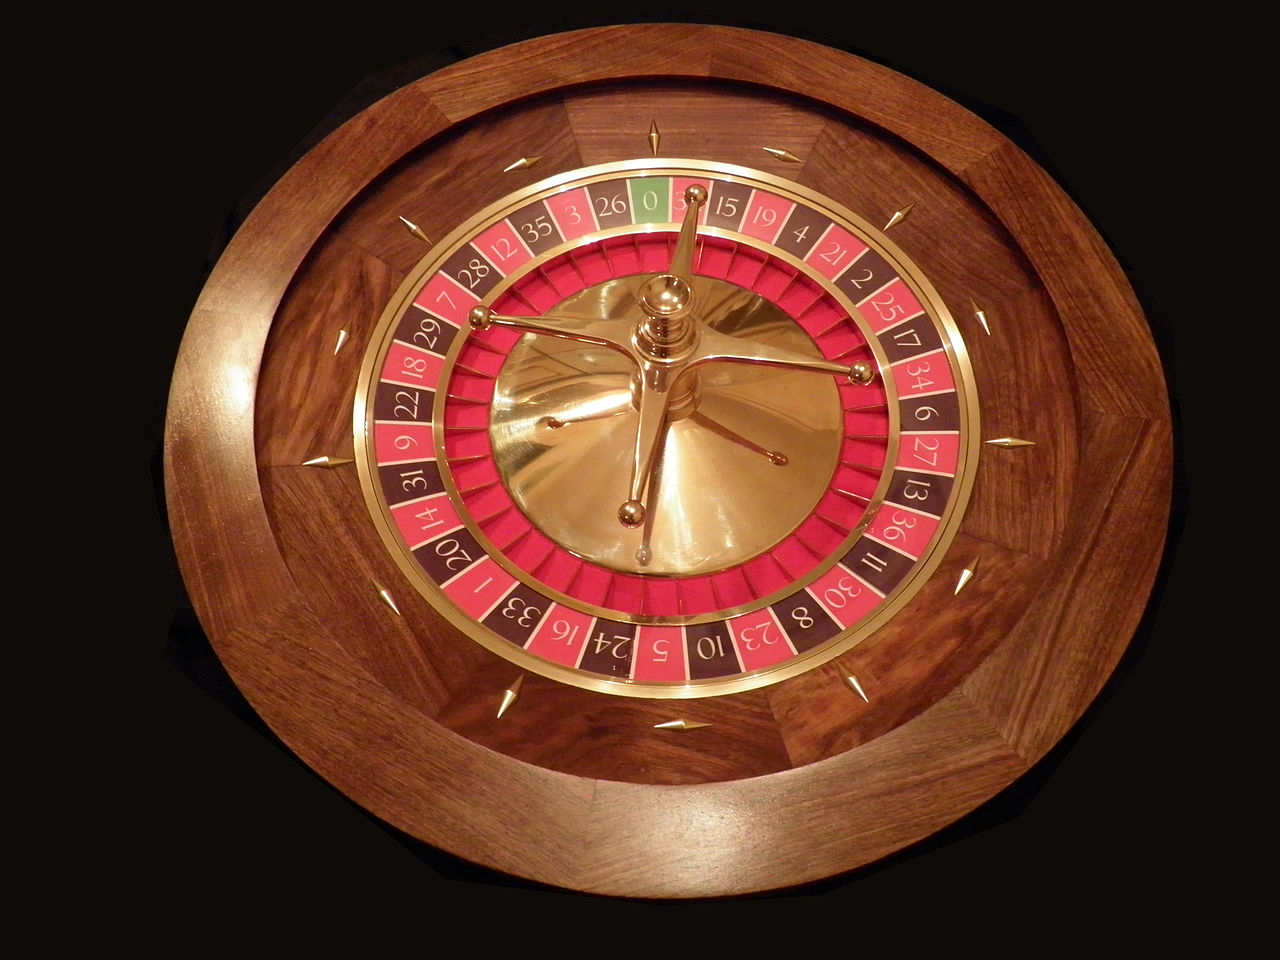

In [2]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/Roulette_casino.JPG"
Image(url, width=600)

One could try to argue with a gambler friend that this is not true using synthetic data, but he might argue back that our random numbers do not reproduce all the atoms of a roulette where the memory of previous rolls is stored. So let us test this using real data from a casino. Most casinos actually keep this data private, but the Wiesbaden Casino in Germany provides information on each of their tables for every day (https://www.spielbank-wiesbaden.de/index.php?id=101). The dataset we will use is a compilation of data for all days in 2018 for Table 1 in the casino. The roulette is of European style, with numbers from 1 to 36 evenly distributed between black and red, and a single green zero.

In [3]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/wiesbaden_table1.txt"
data = pd.read_csv(url)

In [4]:
data.head()

,date,roll,color,number
0,20180101,1,R,5
1,20180101,2,B,28
2,20180101,3,B,2
3,20180101,4,R,34
4,20180101,5,R,14


The columns in the dataset are:
- **date**: the date at which the roll was made (yyyymmdd format)
- **roll**: the number of the roll of the table in the year (data is ordered in time)
- **color**: the color of the roll, with "R" being red, "B" being black and "G" being green
- **number**: the number that was drawn

First we will test if the roulette is fair and then test if repeated draws on this roulette affect the subsequent outcome. Your tasks for this exercise are the following:
- Using a Bayesian analysis, determine the posterior distribution for the probability $\theta$ of drawing a red number.  Use a flat prior for $\theta$ (i.e. $P(\theta)\propto 1$) and evaluate the posterior using the first month of data, the first six months, and the full year. To quantify the uncertainty in the result, consider a 99.73\% probability interval (equivalent to 3-$\sigma$ for a normal distribution) of the posterior by computing the $0.27/2$ and $100-0.27/2$ percentiles of the posterior samples. Within this probability interval, do you find that the roulette is fair? Is this outcome affected if you use a Jeffreys prior $P(\theta)\propto \theta^{-1/2}(1-\theta)^{-1/2}$?
- Using the full dataset, determine the posterior distribution to draw each of the numbers (0-36) in the roulette. Within the 99.73\% probability interval of the posteriors, is any outcome inconsistent with the expected probability? What about within a 95\% probability interval (2-$\sigma$ equivalent)? If you find a mismatch, is it statistically meaningful?
- Now, let us test if repeated draws affect the subsequent result. Any 'good' gambler will tell you that a table loses its memory from one day to the next, so restrict your analysis to groups of draws from individual days. Check the number of red draws happening after two subsequent red draws. For this set, determine the posterior probability $\theta'$ to draw a red ball after 2 previous red balls, and compare this to the posterior probability derived from all the data in the first part of this exercise. Within the 99.73\% probability interval of the posterior, do you see a mismatch?

---

## Task 2: Solar flares

Solar flares are sudden changes in brightness in the surface of the Sun that can be observed in X-rays, and are associated with interactions of the tangled magnetic fields in its surface. In the most extreme cases, large flares can be connected to coronal mass ejections, large blobs of plasma that can travel the solar system at thousands of kilometers per second and cause significant damage if we are unlucky to cross their path. One extreme case was the one observed by the English Solar astrophysicist Richard Carrington on September 1st, 1859. On that date, Carrington observed a large group of sunspots grouped together which suddenly emmited a bright flash of light. The following day, auroras we're visible all over the world, some so bright that they were visible during the day. Despite the beautiful display, the event had a large impact on telegraph networks, and were it to happen today it could result in catastrophic damages to our communication infrastructure and electric grids.

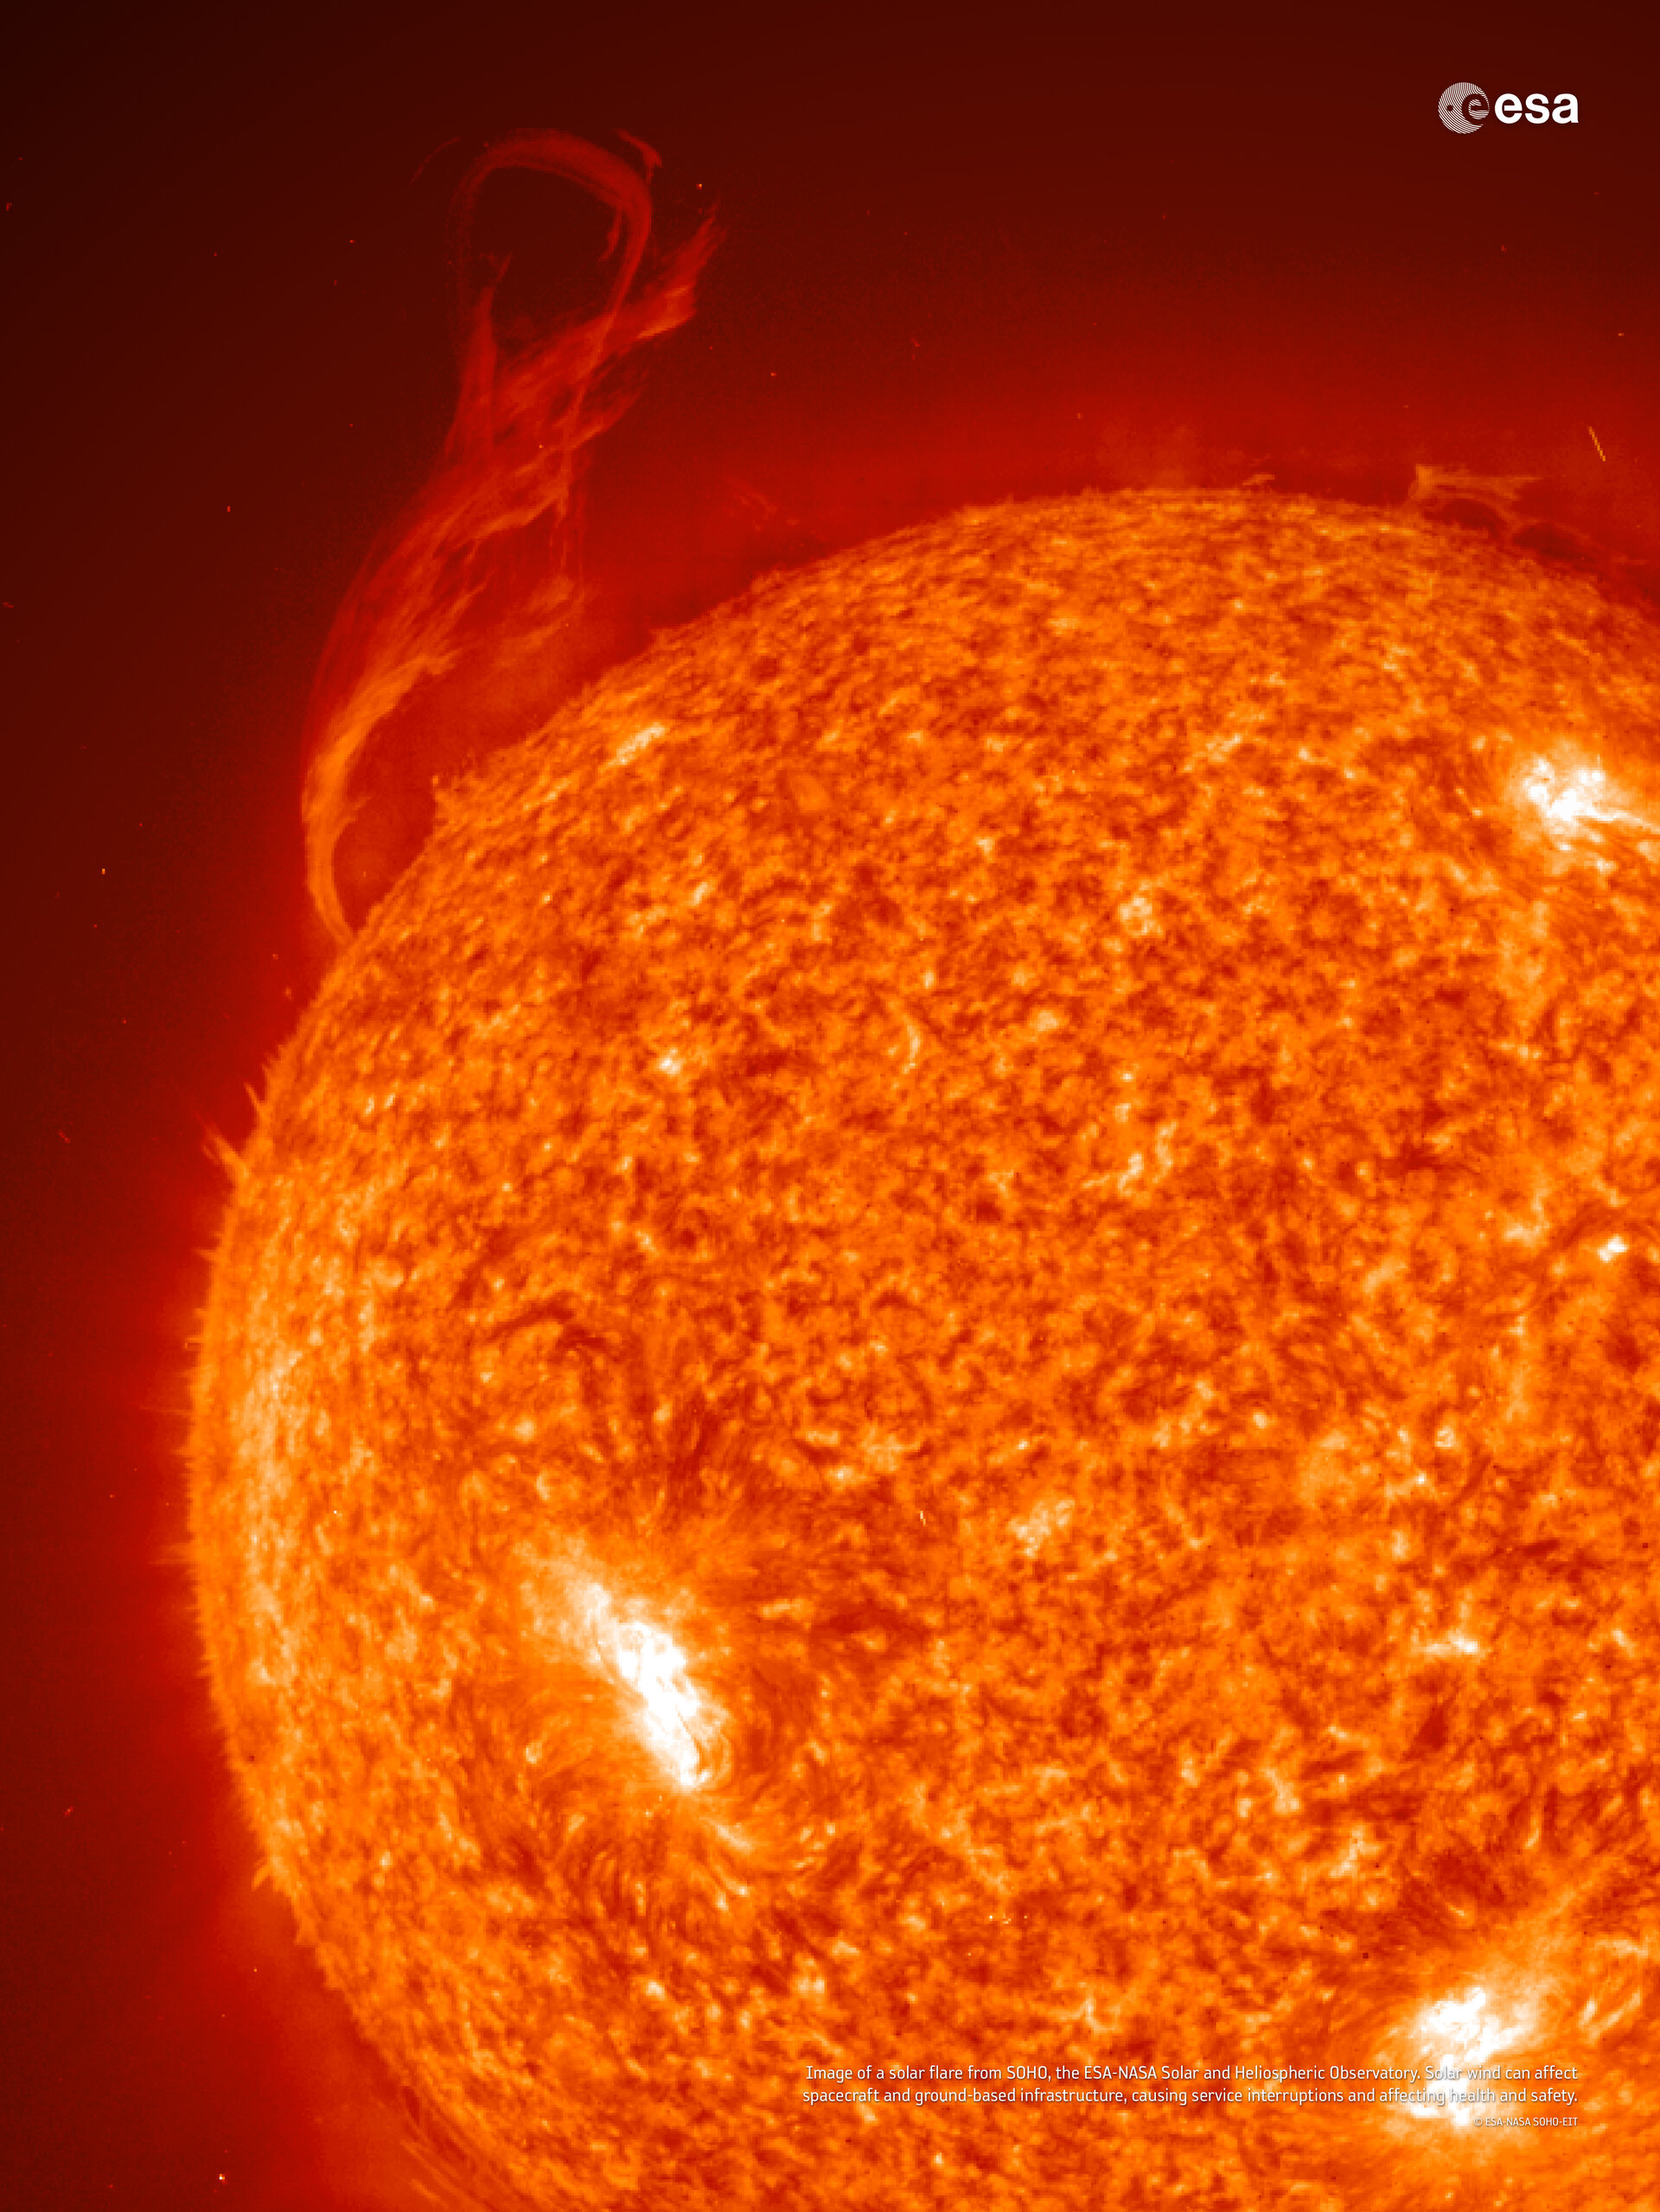

In [5]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/Watching_the_Sun_SOHO_pillars.jpg"
Image(url, width=700)

In this exercise, we will explore a database of solar flares detected by the GOES satellite. GOES is a geostationary satellite that can detect solar flares with its onboard X-ray detector, and the dataset in question was produced using the method of [Ryan et al. (2012)](https://ui.adsabs.harvard.edu/abs/2012ApJS..202...11R/abstract) to properly account for the biases of the instrument. Depending on the maximum energy flux reached by an event, flares are categorized (in order of increasing strength) in classes A, B, C, M and X. The provided dataset is simplified, but if you're interested in it you can download it in full [here](https://data.nas.nasa.gov/helio/portals/solarflares/dataproducts.html).

In [11]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/GOES_flare_data.txt"
data = pd.read_csv(url, sep='\s+')

In [12]:
data.head()

,start_day,start_time,peak_day,peak_time,end_day,end_time,GOES_class
0,20020101,08:59:00,20020101,09:10:00,20020101,09:17:00,C
1,20020102,03:16:00,20020102,03:23:00,20020102,03:27:00,C
2,20020102,03:38:00,20020102,03:41:00,20020102,03:47:00,C
3,20020102,05:33:00,20020102,05:36:00,20020102,05:38:00,C
4,20020102,07:55:00,20020102,08:01:00,20020102,08:08:00,C


The columns in the dataset are:
- **start_day**: the date at which the flare was first detected (yyyymmdd format)
- **start_time**: the time (UT) at which the flare was first detected
- **peak_day**, **peak_time**, **end_day**, **end_time**: Same as the previous two but for the moment of peak energy flux detected by the satellite and for the moment the flare stopped being detected.
- **GOES_class**: classification of the flare according to the energy flux measured by the satellite. Full data provides subcategories beyond the A, B, C, M and X classes, but we just provide the general class of the event here.

For this exercise, we really just need the **start_day** and **GOES_class** data columns.

Your tasks for this exercise are the following:
- First, we will estimate the number of flares per year. For this, we take the yearly number of flares $n$ and model it as a Poisson process with a distribution $f(n,\lambda)=e^{-\lambda}\lambda^{n}/n!$, where $\lambda$ is the expected number of events per year. For each year, compute the posterior of $\lambda$ using the Jeffrey's prior for a Poisson distribution ($p(\lambda)\propto \lambda^{-1/2}$) and determine its median and 99.73% probability interval. Plot your results and discuss if you can state that the rate evolves with time.
- Look for information on the solar cycle and the count of solar spots. Does this match your results from the previous step?
- Can we determine if the relative fraction of different flares changes with time? Consider flares of each type as determined by the **GOES_class** column and for each year compute the fraction of each type to the total number of flares that year. For simplicity, model the fraction of each particular flare independently with a binomial distribution likelihood, and determine posterior distributions, their median and their 99.73% probability intervals (make your own choice on the prior). Discuss whether the data is sufficient to determine if these fractions evolve with time. Note that flares of class A are at the detection limit of the instrument.

---

## Task 3: Supernova neutrinos

When a massive star dies, it becomes a supernova where the core of the star completely collapses. Depending on the mass of the star, the result of this collapse can be the formation of a neutron star, an extremely dense object that can contain around one or two times the mass of the Sun in a radius of about 10 kilometers. At these high densities, most of the protons from which the neutron star is formed undergo an electron capture process, where a proton and an electron combine to form a neutron and a neutrino. From this process, a supernova is not just expected to be associated with a luminous explosion, but also with a burst of neutrinos.

This was one of the motivations behind the construction of neutrino detectors, which potentially allow for the simultaneous detection of an astrophysical event both with light as well as with neutrinos. And that is exactly what was observed in 1987, when a supernova was detected in the Large Magellanic Cloud. Given the proximity of this supernova to us ("only" 168,000 lightyears) the event was recorded in extreme detail, and current observations can see in real time how the ejected material interacts with its surroundings (see the movie below). More important, in the context of this exercise, is that the supernova was close enough to Earth that its neutrino burst (lasting just a few seconds) could be measured in two detectors: the IMB detector in the US and the Kamiokande detector in Japan. This is regarded as the first example of multi-messenger (light as well as neutrinos) astronomy from a source outside the solar system.

![1987a](https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/1987a.gif "1987a")

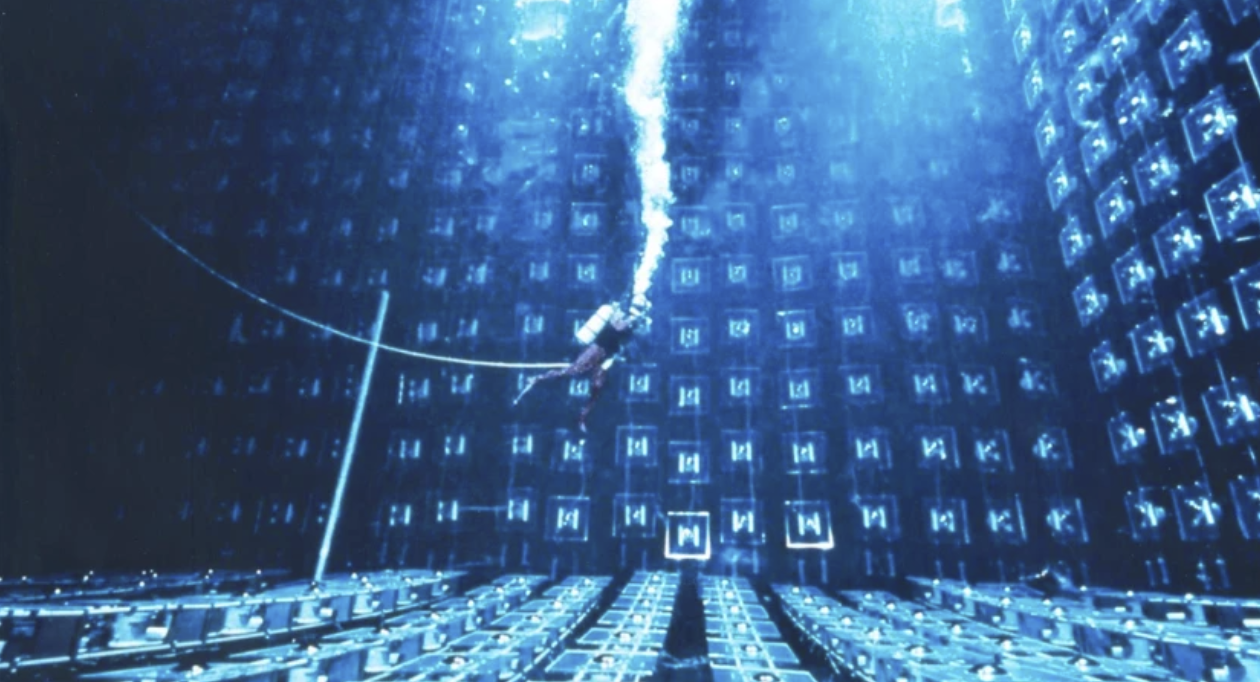

In [17]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/IMB_tank.png"
Image(url, width=1000)

# A picture of the inside of the Irvine-Michigan-Brookhaven (IMB) detector. This Cherenkov detector was built in the Morton salt mine 
# in Ohio and consist of a massive tank of more than 9 million liters of ultra-pure water, and a large network of phototubes attached 
# to the walls. The neutrinos show up by way of their interactions with protons in the water.

The objective of this exercise is to evaluate the significance of the observation made by the IMB detector. The measurement is discussed in [Bionta et al. (1987)](https://ui.adsabs.harvard.edu/abs/1987PhRvL..58.1494B/abstract), where they report the search for a burst in a 6.4 hour period of data from the detector. Separating the data in intervals of 10 seconds, they identified one interval during which 9 events where detected. As the detector is sensitive as well to neutrinos produced by the sun and cosmic rays, it is important to validate that these 9 detections are significant. The provided dataset contains the number of 10-second intervals for which a specific number of events was detected during the aforementioned 6.4 hour period.

In [8]:
data = pd.DataFrame({"events":[0,1,2,3,4,5,6,7,8,9], "number":[1043,860,307,78,15,3,0,0,0,1]})
data

,events,number
0,0,1043
1,1,860
2,2,307
3,3,78
4,4,15
5,5,3
6,6,0
7,7,0
8,8,0
9,9,1


The columns in the dataset are:
- **events**: number of events detected in a 10-second interval
- **number**: number of 10 second intervals with the corresponding number of detected events.

Your tasks for this exercise are to use Bayesian analysis (making your own decision on the priors to use) to answer the following:

- Assuming a Poisson distribution for the events, and ignoring the time interval with 9 events which is the supposed neutrino burst, determine a posterior distribution for the rate of events $\lambda$ using the total number of events detected.
- Since we do not only have the number of events detected in the 6.4 hour period but also the distribution at which specific numbers of events happened in 10-second intervals, we can perform a Bayesian analysis based on the probability of obtaining this precise distribution. The distribution function that describes this is the multinomial distribution, a generalization of the binomial distribution function that can be used to model loaded dice, for example. Look up the form of this distribution.<br><br>
To model the process with a multinomial distribution, denote by $k_i$ the number of 10-second intervals out of a total of $n$ intervals for which $i$ events were detected, and by $k_{\geq 6}$ the number of 10-second intervals for which 6 or more events were detected (which is $k_{\geq 6}=0$ if we exclude the supposed neutrino burst). The probability of drawing exactly a specific set of $\{k_0,k_1,k_2,k_3,k_4,k_5,k_{\geq 6}\}$ for a given value of the rate $\lambda$ is then given by a multinomial distribution function with 7 outcomes and $n$ draws, where the probability of each outcome can be computed from a Poisson distribution. Use this probability distribution as the likelihood in a Bayesian analysis to determine a posterior distribution for $\lambda$, Using the same prior as in the previous part of the exercise.<br><br>
<font color='red'>**Warning:** </font> evaluating the multinomial probability distribution can be tricky for large $n$ as parts of it can overflow the precision of integer numbers in your computer for large $n$. We recommend you use the [scipy implementation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multinomial.html).
- Compare the two posterior distributions derived. Does the posterior that uses the full distribution of the events provide a better constraint on $\lambda$? Can you explain the result?
- Given your posteriors on the rate $\lambda$, estimate the probability that the 9 event interval was randomly produced given the rate estimate and the 6.4 hour interval for the search. Assuming the detection by the Japanese Kamiokande detector was of equal significance, discuss how this increases the likelihood of the event being a true anomaly associated with the supernova.